# Summary of all benchmarks (Fig. 2) and simulation sensitivity

Fig. 2 collects, for each method, the fraction of true signal kept (sensitivity) and of noise removed (specificity)
on the simulation, the human-mouse mixture, PBMC 8k and 8 cubed, plus idempotency and CPU runtime. Every number is
read from the outputs of the notebooks that compute it:

| rows | notebook | file |
|---|---|---|
| Simulation | this notebook (section 1) | `simulation1_small_noise/sensitivity/simulation_sensitivity_metrics.csv` |
| Human-Mouse | `benchmarking.ipynb` (`hgmm_12k`) | `hgmm_12k/hgmm_signal_noise_quantification.csv` |
| PBMC | `benchmarking.ipynb` (`pbmc8k`), dot-plot markers | `pbmc8k/dotplot_signal_noise_quantification.csv` |
| 8 cubed | `8cube.ipynb` | `8cubed/sensitivity_specificity_summary.csv` |
| Runtime | `runtime.ipynb` | `pbmc8k/runtime/runtime_minutes.csv` |
| Idempotent | `idempotency.ipynb` (Fig. 7) | set below |

In [1]:
import os
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from scipy import sparse

import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
output_dir = os.path.join(cellsweep_dir, "notebooks", "output")
sim_data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "simulation1_small_noise")
sens_out_dir = os.path.join(output_dir, "simulation1_small_noise", "sensitivity")
os.makedirs(sens_out_dir, exist_ok=True)
overwrite = False   # recompute the simulation scores even if saved

## 1. Simulation sensitivity and specificity

On `simulation1_small_noise` (outputs of `benchmarking.ipynb`), every tool is scored with the element-wise confusion
components of `cellsweep.utils.evaluate_simulation_denoising` on rounded counts, over the cells retained by all tools:

TP = min(Yp, Yt), FP = max(0, Yp − Yt), FN = max(0, Yt − Yp), TN = max(0, Yr − TP − FP − FN);
sensitivity = TP / (TP + FN), specificity = TN / (TN + FP),

with Yr the raw counts, Yt the true signal (`layers["real"]`) and Yp the tool output. The panels show the global
scores (A), the per-cell signal removed (B), against the true ambient fraction (C), by gene expression (D), and
per cell type (E).

In [2]:
TOOLS = ["CellSweep", "CellBender", "DecontX", "scAR", "SoupX"]  # Figure 2 column order
# Categorical slots of the validated default palette (same assignment as make_janssen_figure.py).
METHOD_COLORS = {"CellSweep": "#2a78d6", "CellBender": "#eb6834", "DecontX": "#1baf7a",
                 "scAR": "#eda100", "SoupX": "#4a3aa7"}
METHOD_MARKERS = {"CellSweep": "o", "CellBender": "s", "DecontX": "D", "scAR": "v", "SoupX": "^"}
INK, MUTED, GRID = "#26251f", "#6f6e69", "#e4e3de"
BLUES = LinearSegmentedColormap.from_list(
    "palette_blue", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
                     "#256abf", "#184f95", "#0d366b"])
# Panel A label offsets (points); CellSweep and DecontX sit nearly on top of each other.
LABEL_OFFSETS = {"CellSweep": (-14, 10), "CellBender": (-14, 12), "DecontX": (12, -2), "scAR": (10, -4),
                 "SoupX": (-14, 2)}
FLOOR = 1e-5  # log-axis floor for cells/genes that lose no signal
def load_tools():
    raw = cs_utils.load_adata(os.path.join(sim_data_dir, "adata_raw.h5ad"))
    raw.var_names_make_unique()
    tools = {}
    cs = ad.read_h5ad(os.path.join(sim_data_dir, "sim1_output_cellsweep.h5ad"))
    tools["CellSweep"] = cs[~cs.obs["is_empty"]].copy()
    tools["CellBender"] = sc.read_10x_h5(os.path.join(sim_data_dir, "sim1_output_cellbender_filtered.h5"), gex_only=False)
    tools["SoupX"] = cs_utils.load_adata(os.path.join(sim_data_dir, "sim1_output_soupx"))
    dx = cs_utils.load_adata(os.path.join(sim_data_dir, "sim1_output_decontx"))
    dx.obs_names = [n.replace("GRCh38_", "", 1) for n in dx.obs_names]
    tools["DecontX"] = dx
    tools["scAR"] = ad.read_h5ad(os.path.join(sim_data_dir, "sim1_output_scar.h5ad"))
    for a in tools.values():
        a.var_names_make_unique()
    common = sorted(set.intersection(*[set(a.obs_names) for a in tools.values()]))
    return raw, tools, common
def _rint(X):
    X = sparse.csr_matrix(X, dtype=np.float64)
    X.data = np.rint(X.data)
    X.eliminate_zeros()
    return X
def confusion(Yp, Yt, Yr):
    """Element-wise TP/FP/FN/TN matrices, as in evaluate_simulation_denoising."""
    TP = Yp.minimum(Yt)
    FP = (Yp - Yt).maximum(0)
    FN = (Yt - Yp).maximum(0)
    TN = (Yr - TP - FP - FN).maximum(0)
    return TP, FP, FN, TN
def _sum(M, axis):
    return np.asarray(M.sum(axis=axis)).ravel()
def compute(raw, tools, common):
    raw = raw[common].copy()
    genes = raw.var_names
    Yr, Yt = _rint(raw.X), _rint(raw.layers["real"])
    is_marker = raw.var["is_marker"].to_numpy().astype(bool)
    celltype = raw.obs["celltype"].astype(str).to_numpy()
    ambient = raw.obs["true_ambient_fraction" if "true_ambient_fraction" in raw.obs else "ambient_fraction"].to_numpy()
    true_mean = _sum(Yt, 0) / Yt.shape[0]

    global_rows, cell_rows, gene_rows, ct_rows = [], [], [], []
    for tool in TOOLS:
        a = tools[tool][common, genes]
        Yp = _rint(a.X)
        TP, FP, FN, TN = confusion(Yp, Yt, Yr)
        for scope, cols in (("marker genes", is_marker), ("all genes", slice(None))):
            tp, fp, fn, tn = (M[:, cols].sum() for M in (TP, FP, FN, TN))
            global_rows.append(dict(tool=tool, genes=scope, sensitivity=tp / (tp + fn),
                                    specificity=tn / (tn + fp), ppv=tp / (tp + fp),
                                    TP=tp, FP=fp, FN=fn, TN=tn))
        # per cell, marker genes
        tp_c, fn_c = _sum(TP[:, is_marker], 1), _sum(FN[:, is_marker], 1)
        cell_rows.append(pd.DataFrame(dict(tool=tool, celltype=celltype, ambient_fraction=ambient,
                                           TP=tp_c, FN=fn_c, signal=tp_c + fn_c)))
        # per gene, all genes
        tp_g, fn_g = _sum(TP, 0), _sum(FN, 0)
        gene_rows.append(pd.DataFrame(dict(tool=tool, gene=genes, is_marker=is_marker,
                                           true_mean=true_mean, TP=tp_g, FN=fn_g)))
    cells = pd.concat(cell_rows, ignore_index=True)
    cells["signal_removed"] = cells["FN"] / cells["signal"].clip(lower=1)
    genes_df = pd.concat(gene_rows, ignore_index=True)
    genes_df["signal_removed"] = genes_df["FN"] / (genes_df["TP"] + genes_df["FN"]).clip(lower=1)
    ct = cells.groupby(["tool", "celltype"])[["TP", "FN"]].sum().reset_index()
    ct["sensitivity"] = ct["TP"] / (ct["TP"] + ct["FN"])
    return pd.DataFrame(global_rows), cells, genes_df, ct
# ---------------------------------------------------------------- plotting helpers
def _style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelcolor=INK, labelsize=8)
    ax.grid(color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
def _label(ax, letter):
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes, fontsize=14, fontweight="bold", va="top", color=INK)
def panel_global(ax, g):
    for tool in TOOLS:
        for scope, fill in (("marker genes", True), ("all genes", False)):
            r = g[(g.tool == tool) & (g.genes == scope)].iloc[0]
            c = METHOD_COLORS[tool]
            ax.scatter(r.specificity, max(1 - r.sensitivity, FLOOR), s=70, marker=METHOD_MARKERS[tool],
                       facecolor=c if fill else "white", edgecolor=c, linewidth=1.8, zorder=3)
        r = g[(g.tool == tool) & (g.genes == "marker genes")].iloc[0]
        ax.annotate(tool, (r.specificity, max(1 - r.sensitivity, FLOOR)), xytext=LABEL_OFFSETS[tool],
                    textcoords="offset points", fontsize=8, color=INK, ha="right" if LABEL_OFFSETS[tool][0] < 0 else "left",
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6))
    ax.set_yscale("log")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Specificity (fraction of noise removed)", fontsize=9, color=INK)
    ax.set_ylabel("1 − sensitivity\n(fraction of true signal removed)", fontsize=9, color=INK)
    ax.scatter([], [], marker="o", facecolor=MUTED, edgecolor=MUTED, label="marker genes")
    ax.scatter([], [], marker="o", facecolor="white", edgecolor=MUTED, label="all genes")
    ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc="center left")
    ax.text(0.03, 0.03, "better: right and down", transform=ax.transAxes, fontsize=8, color=MUTED)
    _style(ax)
def panel_ecdf(ax, cells):
    for tool in TOOLS:
        v = np.sort(np.maximum(cells.loc[cells.tool == tool, "signal_removed"].to_numpy(), FLOOR))
        ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post", color=METHOD_COLORS[tool], lw=2)
    ax.set_xscale("log")
    ax.set_xlim(FLOOR * 0.7, 1)
    ax.set_xlabel(f"Fraction of true marker signal removed per cell\n(cells removing none plotted at {FLOOR:g})",
                  fontsize=9, color=INK)
    ax.set_ylabel("Cumulative fraction of cells", fontsize=9, color=INK)
    _style(ax)
def panel_ambient(ax, cells):
    x0 = cells.loc[cells.tool == TOOLS[0], "ambient_fraction"].to_numpy()
    edges = np.quantile(x0, np.linspace(0, 1, 11))
    for tool in TOOLS:
        d = cells[cells.tool == tool]
        # signal removed per cell = total marker FN / total marker signal within the bin
        idx = np.clip(np.digitize(d.ambient_fraction, edges[1:-1]), 0, len(edges) - 2)
        agg = d.assign(bin=idx).groupby("bin").agg(x=("ambient_fraction", "median"), FN=("FN", "sum"),
                                                   S=("signal", "sum"))
        ax.plot(agg.x, np.maximum(agg.FN / agg.S, FLOOR), color=METHOD_COLORS[tool], lw=2,
                marker=METHOD_MARKERS[tool], ms=5, markeredgecolor="white", markeredgewidth=0.8)
    ax.set_yscale("log")
    ax.set_xlabel("True ambient fraction of cell (decile median)", fontsize=9, color=INK)
    ax.set_ylabel("Fraction of true marker signal removed", fontsize=9, color=INK)
    _style(ax)
def panel_gene_expression(ax, genes_df):
    g0 = genes_df[genes_df.tool == TOOLS[0]]
    expressed = g0.true_mean > 0
    edges = np.quantile(g0.true_mean[expressed], np.linspace(0, 1, 11))
    for tool in TOOLS:
        d = genes_df[(genes_df.tool == tool) & (genes_df.true_mean > 0)]
        idx = np.clip(np.digitize(d.true_mean, edges[1:-1]), 0, len(edges) - 2)
        agg = d.assign(bin=idx).groupby("bin").agg(x=("true_mean", "median"), FN=("FN", "sum"), TP=("TP", "sum"))
        ax.plot(agg.x, np.maximum(agg.FN / (agg.FN + agg.TP), FLOOR), color=METHOD_COLORS[tool], lw=2,
                marker=METHOD_MARKERS[tool], ms=5, markeredgecolor="white", markeredgewidth=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("True mean expression of gene (decile median, all genes)", fontsize=9, color=INK)
    ax.set_ylabel("Fraction of true signal removed", fontsize=9, color=INK)
    _style(ax)
def panel_celltype(ax, fig, ct):
    order = sorted(ct.celltype.unique(), key=lambda s: int(s.split("_")[-1]))
    lost = ct.assign(lost=1 - ct.sensitivity).pivot(index="tool", columns="celltype", values="lost").loc[TOOLS, order]
    sens = ct.pivot(index="tool", columns="celltype", values="sensitivity").loc[TOOLS, order]
    norm = LogNorm(vmin=1e-4, vmax=0.5)
    im = ax.imshow(np.clip(lost.to_numpy(), 1e-4, 0.5), cmap=BLUES, norm=norm, aspect="auto")
    for i in range(len(TOOLS)):
        for j in range(len(order)):
            v = sens.iat[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7,
                    color="white" if lost.iat[i, j] > 0.01 else INK)
    ax.set_yticks(range(len(TOOLS)), TOOLS, fontsize=8, color=INK)
    ax.set_xticks(range(len(order)), [o.replace("_", " ") for o in order], rotation=45, ha="right",
                  fontsize=8, color=INK)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title("Marker-gene sensitivity by cell type (text); color = 1 − sensitivity",
                 fontsize=9, color=INK, loc="left")
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label("1 − sensitivity", fontsize=8, color=INK)
    cb.ax.tick_params(labelsize=7, colors=MUTED, labelcolor=INK)
    cb.outline.set_visible(False)
def make_sensitivity_figure(g, cells, genes_df, ct, out_dir):
    mpl.rcParams["font.family"] = "DejaVu Sans"
    fig = plt.figure(figsize=(13, 11))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.8], hspace=0.5, wspace=0.3)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 0]),
            fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[2, :])]
    panel_global(axes[0], g)
    panel_ecdf(axes[1], cells)
    panel_ambient(axes[2], cells)
    panel_gene_expression(axes[3], genes_df)
    panel_celltype(axes[4], fig, ct)
    handles = [plt.Line2D([], [], color=METHOD_COLORS[t], marker=METHOD_MARKERS[t], lw=2, ms=6, label=t)
               for t in TOOLS]
    fig.legend(handles=handles, loc="upper center", ncol=len(TOOLS), frameon=False, fontsize=9,
               labelcolor=INK, bbox_to_anchor=(0.5, 0.94))
    for ax, letter in zip(axes, "ABCDE"):
        _label(ax, letter)
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(out_dir, f"simulation_sensitivity.{ext}"), dpi=300, bbox_inches="tight")
    plt.close(fig)

      tool        genes  sensitivity  specificity    ppv
 CellSweep marker genes       0.9989       0.8747 0.9948
 CellSweep    all genes       0.9951       0.3882 0.9751
CellBender marker genes       0.9987       0.8759 0.9949
CellBender    all genes       0.9695       0.4956 0.9789
   DecontX marker genes       0.9988       0.8763 0.9949
   DecontX    all genes       0.9950       0.3841 0.9749
      scAR marker genes       0.7698       0.1452 0.7745
      scAR    all genes       0.6758       0.0820 0.6827
     SoupX marker genes       0.9996       0.8543 0.9940
     SoupX    all genes       0.9980       0.3515 0.9737


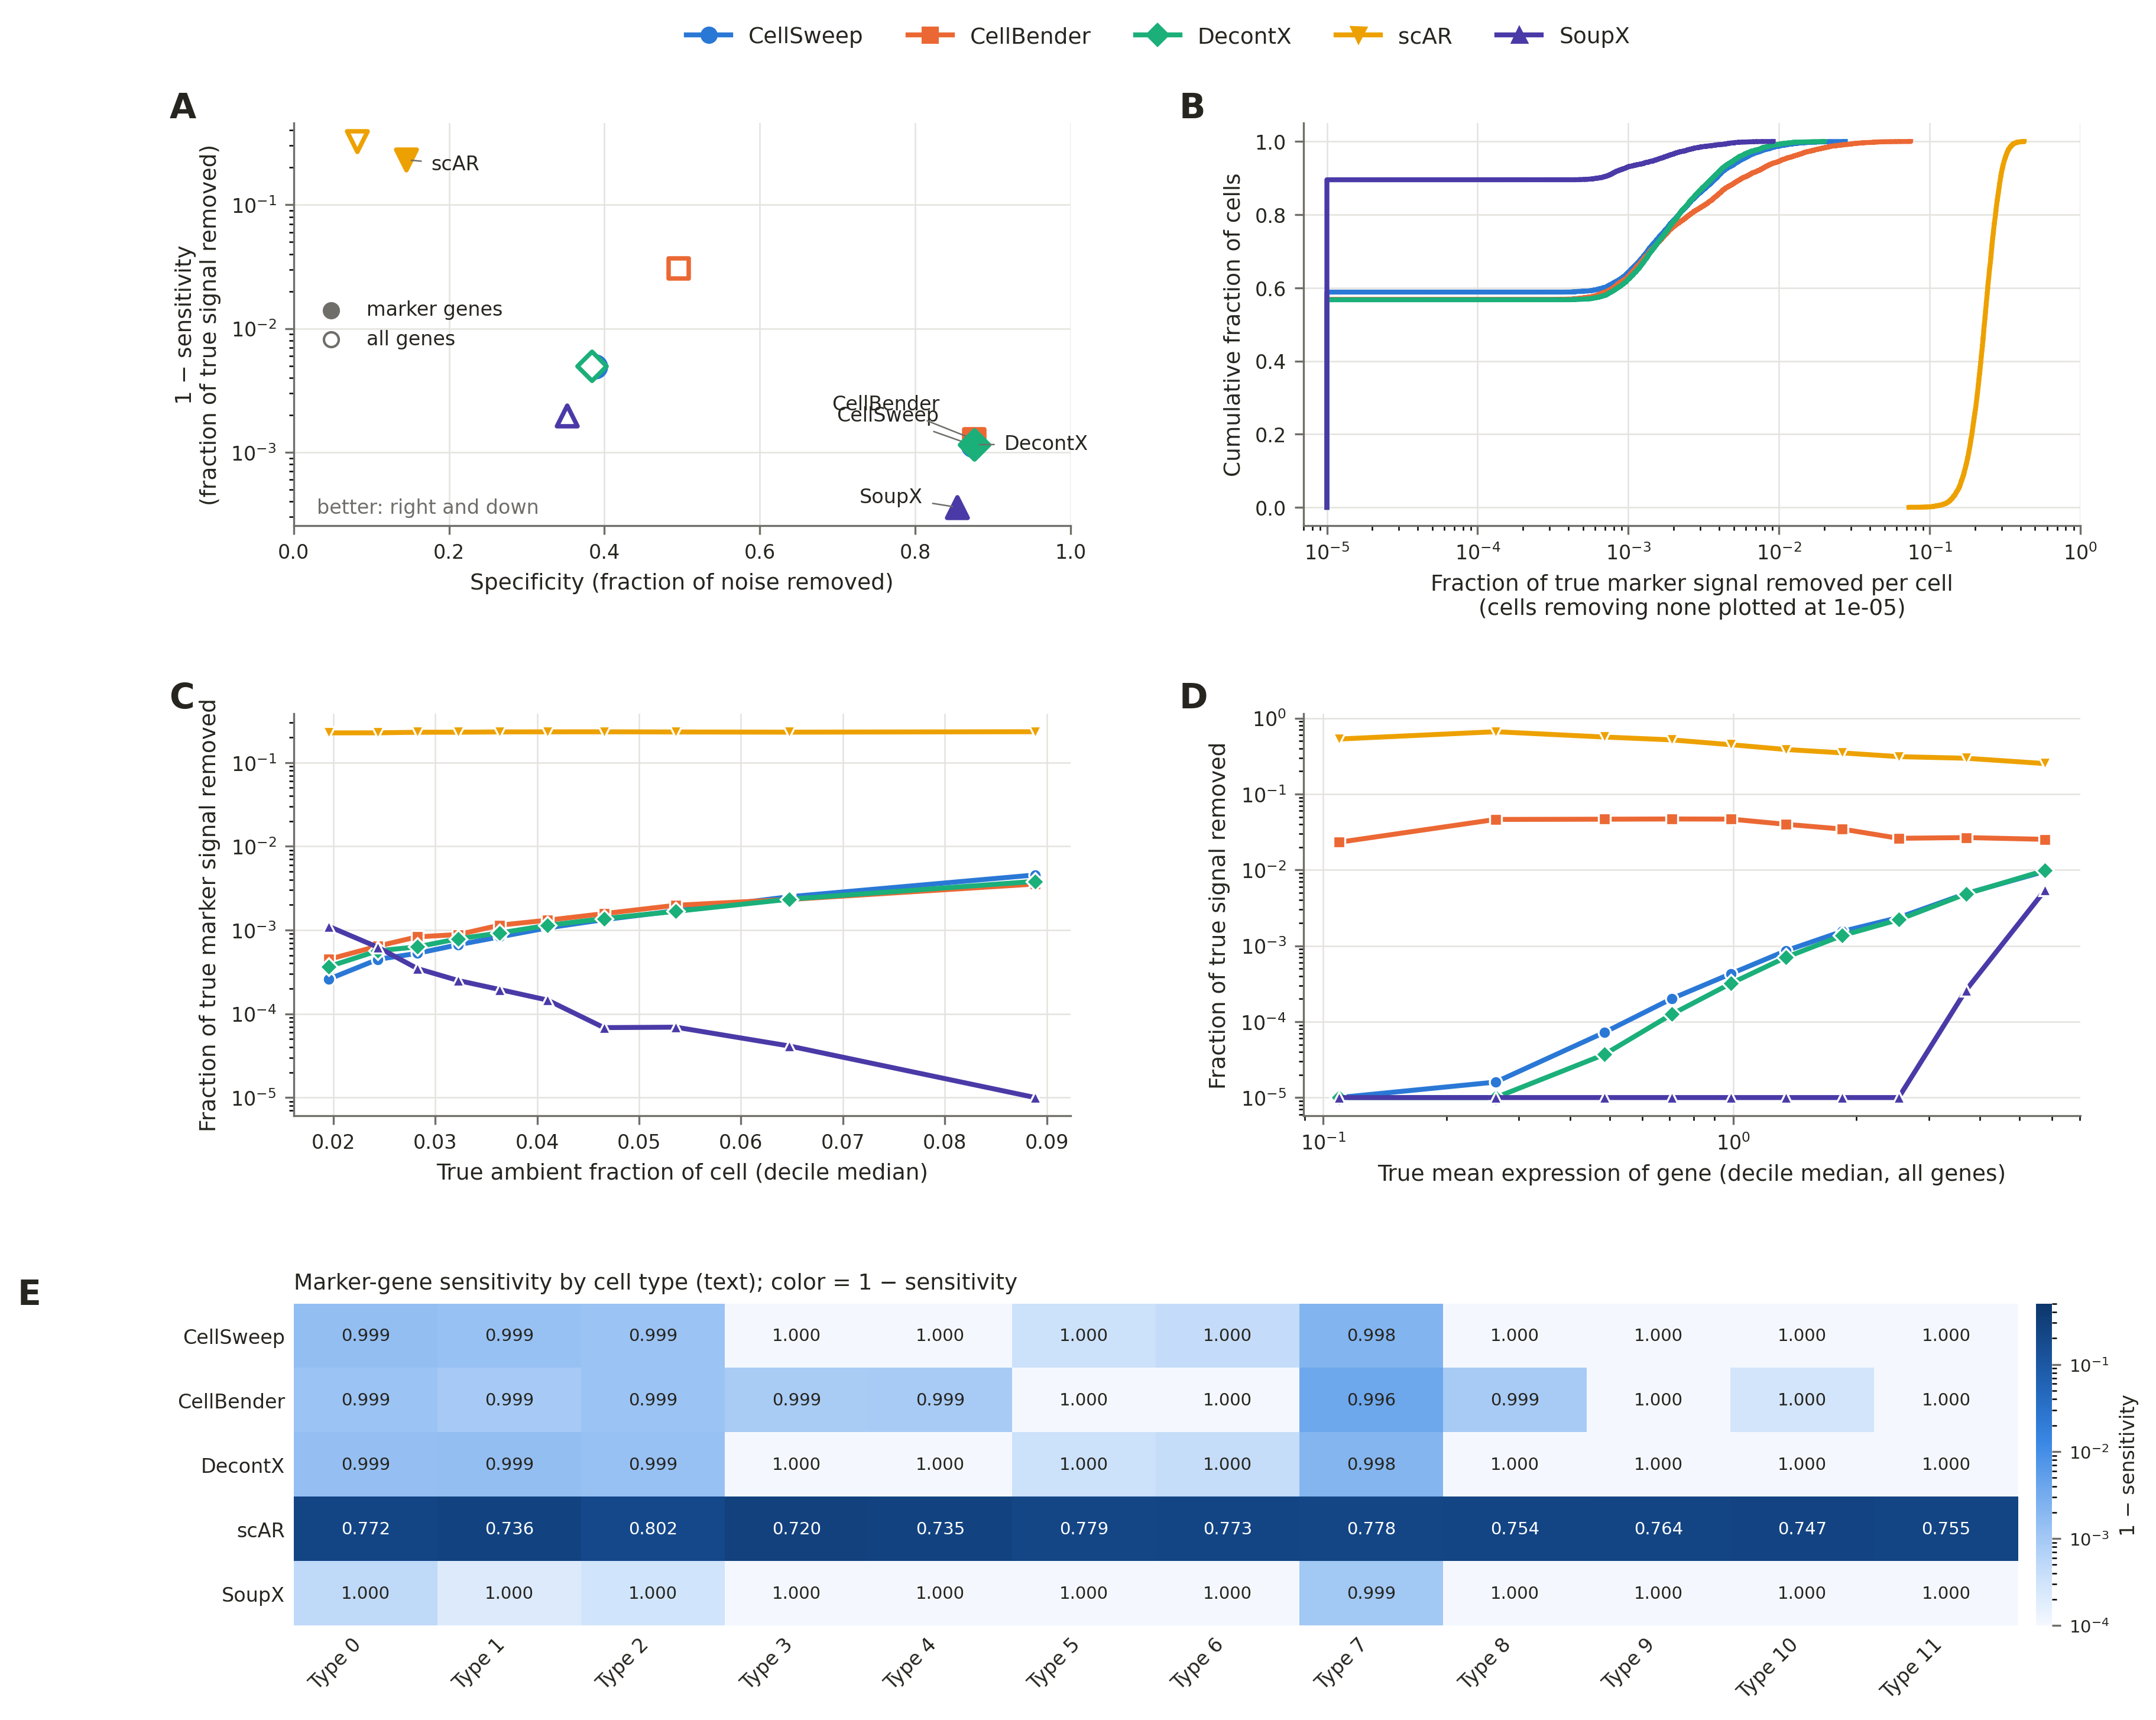

In [3]:
paths = {k: os.path.join(sens_out_dir, f"simulation_sensitivity_{k}.csv") for k in ("metrics", "cells", "genes", "celltype")}
if all(os.path.exists(v) for v in paths.values()) and not overwrite:
    g, cells, genes_df, ct = (pd.read_csv(paths[k]) for k in ("metrics", "cells", "genes", "celltype"))
else:
    raw, tools, common = load_tools()
    print(f"{len(common)} cells retained by all tools")
    g, cells, genes_df, ct = compute(raw, tools, common)
    for k, df in zip(("metrics", "cells", "genes", "celltype"), (g, cells, genes_df, ct)):
        df.to_csv(paths[k], index=False)
print(g[["tool", "genes", "sensitivity", "specificity", "ppv"]].round(4).to_string(index=False))
make_sensitivity_figure(g, cells, genes_df, ct, sens_out_dir)
display(Image(os.path.join(sens_out_dir, "simulation_sensitivity.png"), width=900))

## 2. Fig. 2

Count-weighted scores; PBMC averages the per-marker scores weighted by raw signal and raw noise counts. Cells are
colored on RdYlGn clipped to [0.5, 1]; runtimes on PBMC 8k with 16 CPU threads for CellSweep and CellBender, scAR on
CPU, DecontX and SoupX as run in `runtime.ipynb`.

In [3]:
# order: CellSweep, CellBender, DecontX, scAR, SoupX (idempotency.ipynb, Fig. 7)
IDEMPOTENT = ["Yes", "No", "Yes", "No", "Yes"]
FAST_MIN = 3  # runtimes at or below this are colored good, otherwise bad


def make_heatmap(rows, runtime_min, out_base):
    cmap = plt.get_cmap("RdYlGn")
    norm = mpl.colors.Normalize(vmin=0.5, vmax=1.0)
    n_rows = len(rows) + 2

    fig, ax = plt.subplots(figsize=(7, 0.62 * n_rows + 0.8))

    def cell(i, j, color, text, text_color):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color, ec="white", lw=2))
        ax.text(j + 0.5, i + 0.5, text, ha="center", va="center", fontsize=10, color=text_color)

    for i, (_, vals) in enumerate(rows):
        for j, v in enumerate(vals):
            if np.isnan(v):
                cell(i, j, "lightgray", "N/A", "black")
            else:
                cell(i, j, cmap(norm(max(v, 0.5))), f"{v:.3f}", "white" if (v >= 0.9 or v < 0.6) else "black")
    i = len(rows)
    for j, v in enumerate(IDEMPOTENT):
        cell(i, j, cmap(norm(1.0 if v == "Yes" else 0.5)), v, "white")
    i += 1
    for j, v in enumerate(runtime_min):
        cell(i, j, cmap(norm(0.98 if v <= FAST_MIN else 0.5)), f"{v:.1f}" if v < 10 else f"{v:.0f}", "white")

    ax.set_xlim(0, len(TOOLS))
    ax.set_ylim(n_rows, 0)
    ax.set_yticks(np.arange(n_rows) + 0.5, [r[0] for r in rows] + ["Idempotent", "Runtime on CPU (min)"])
    ax.set_xticks(np.arange(len(TOOLS)) + 0.5, TOOLS, rotation=30, ha="left")
    ax.xaxis.tick_top()

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(sm, ax=ax, fraction=0.05, pad=0.04, shrink=0.8)
    cb.set_ticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0], labels=["≤0.5", "0.6", "0.7", "0.8", "0.9", "1.0"])
    cb.set_label("Normalized score")

    os.makedirs(os.path.dirname(out_base), exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(f"{out_base}.{ext}", dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Wrote {out_base}.png and {out_base}.pdf")

                         CellSweep  CellBender  DecontX   scAR  SoupX
Simulation sensitivity       0.999       0.999    0.999  0.770  1.000
Simulation specificity       0.875       0.876    0.876  0.145  0.854
Human-Mouse sensitivity      0.981       0.991    0.981  0.975  0.983
Human-Mouse specificity      0.989       0.956    0.712  0.987  0.734
PBMC sensitivity             0.950       0.989    0.940  0.854  0.977
PBMC specificity             0.902       0.805    0.842  0.850  0.804
8 cubed sensitivity          0.973       0.986    0.970    NaN  0.987
8 cubed specificity          0.951       0.902    0.898    NaN  0.404
runtime (min): {'CellSweep': 0.68, 'CellBender': 128.93, 'DecontX': 2.19, 'scAR': 24.55, 'SoupX': 1.61}


Wrote /home/mcaskey/cellsweep/notebooks/output/Fig2.png and /home/mcaskey/cellsweep/notebooks/output/Fig2.pdf


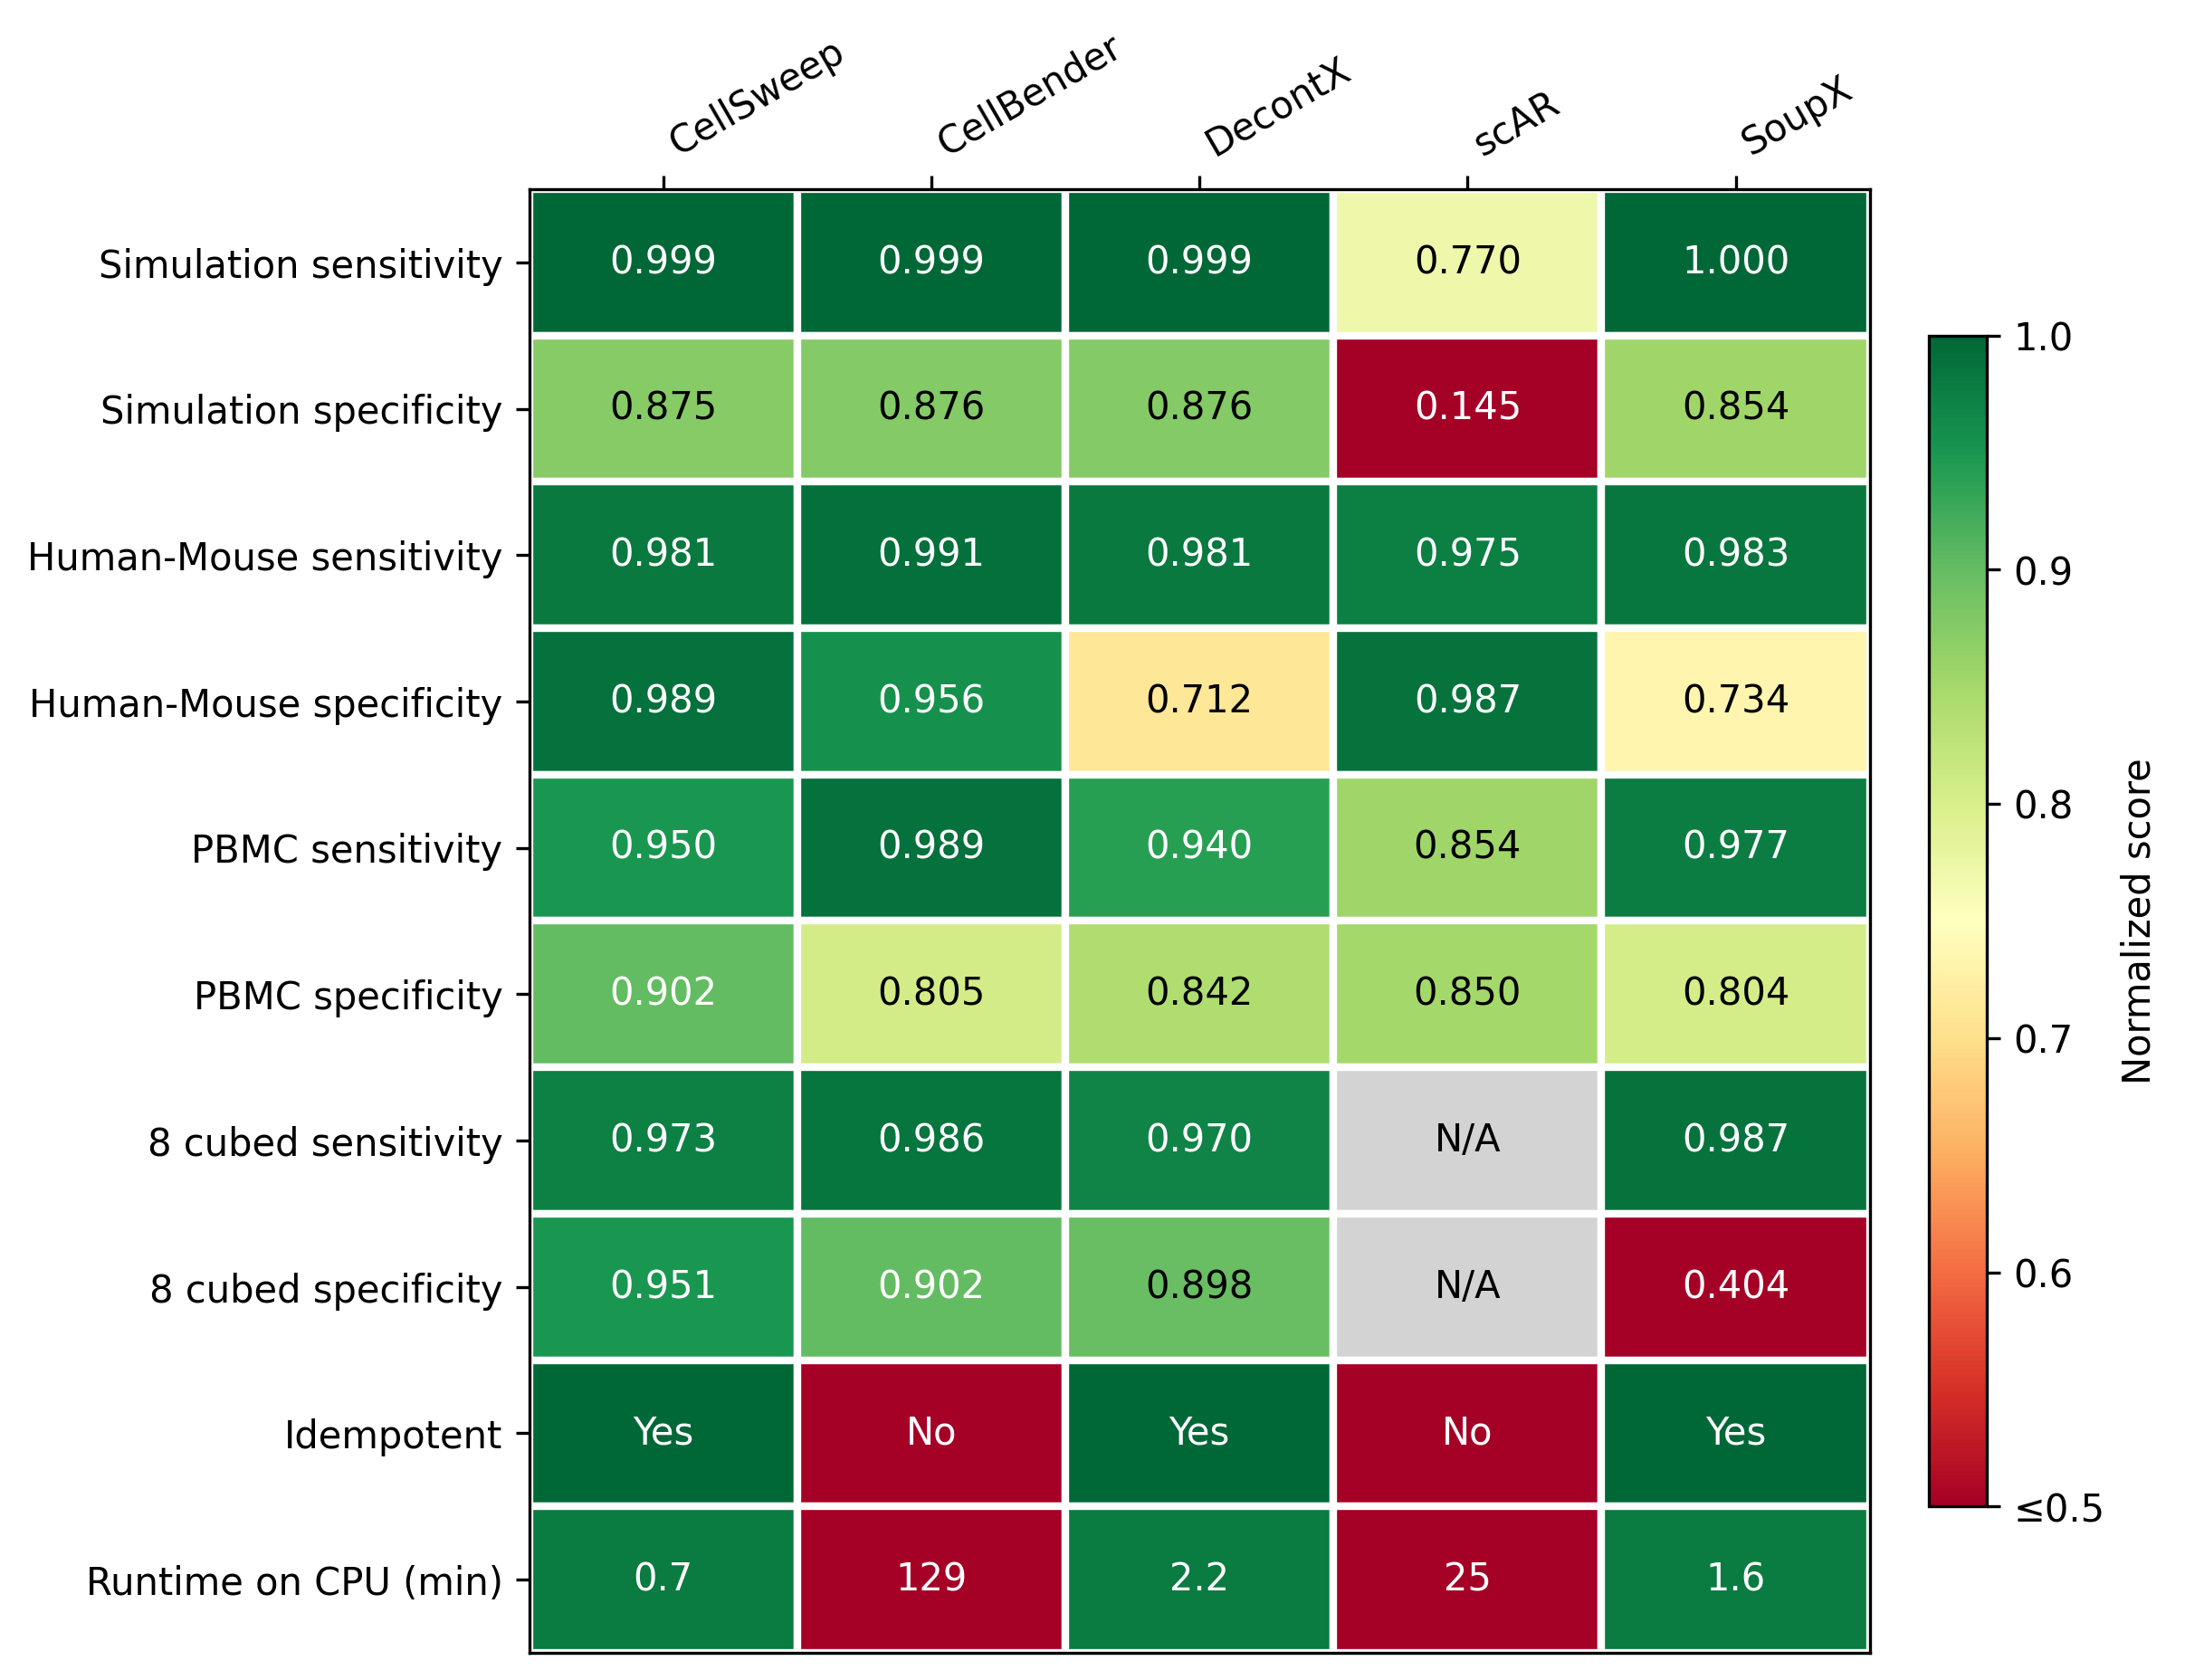

In [4]:
key = {"CellSweep": "cellsweep", "CellBender": "cellbender", "DecontX": "decontx", "scAR": "scar", "SoupX": "soupx"}

sim = pd.read_csv(os.path.join(sens_out_dir, "simulation_sensitivity_metrics.csv"))
sim = sim[sim["genes"] == "marker genes"].set_index("tool")

hgmm = pd.read_csv(os.path.join(output_dir, "hgmm_12k", "hgmm_signal_noise_quantification.csv")).set_index("tool")

pbmc = pd.read_csv(os.path.join(output_dir, "pbmc8k", "dotplot_signal_noise_quantification.csv"))
pbmc = pbmc[pbmc["on_target"] != "(broad control)"].groupby("tool")[["signal_retained", "noise_removed", "raw_signal", "raw_noise"]].apply(lambda d: pd.Series({
    "signal_retained": np.average(d["signal_retained"], weights=d["raw_signal"]),
    "noise_removed": np.average(d["noise_removed"], weights=d["raw_noise"])}))

cube = pd.read_csv(os.path.join(output_dir, "8cubed", "sensitivity_specificity_summary.csv")).set_index("tool")
cube = cube.reindex(list(key.values()))   # scAR was not run on 8 cubed

runtime = pd.read_csv(os.path.join(output_dir, "pbmc8k", "runtime", "runtime_minutes.csv"), index_col=0)["minutes"]
runtime_tool = {"CellSweep": "cellsweep_16threads", "CellBender": "cellbender_cpu_16threads", "DecontX": "decontx",
                "scAR": "scar_cpu", "SoupX": "soupx"}

rows = [
    ("Simulation sensitivity", [sim.loc[t, "sensitivity"] for t in TOOLS]),
    ("Simulation specificity", [sim.loc[t, "specificity"] for t in TOOLS]),
    ("Human-Mouse sensitivity", [hgmm.loc[key[t], "signal_retained"] for t in TOOLS]),
    ("Human-Mouse specificity", [hgmm.loc[key[t], "noise_removed"] for t in TOOLS]),
    ("PBMC sensitivity", [pbmc.loc[key[t], "signal_retained"] for t in TOOLS]),
    ("PBMC specificity", [pbmc.loc[key[t], "noise_removed"] for t in TOOLS]),
    ("8 cubed sensitivity", [cube.loc[key[t], "sensitivity_weighted"] for t in TOOLS]),
    ("8 cubed specificity", [cube.loc[key[t], "specificity_weighted"] for t in TOOLS]),
]
runtime_min = [runtime[runtime_tool[t]] for t in TOOLS]
print(pd.DataFrame({r: v for r, v in rows}, index=TOOLS).T.round(3).to_string())
print("runtime (min):", {t: round(float(v), 2) for t, v in zip(TOOLS, runtime_min)})
make_heatmap(rows, runtime_min, os.path.join(output_dir, "Fig2"))
display(Image(os.path.join(output_dir, "Fig2.png"), width=600))